In [1]:
import gmsh
import ufl
import pyvista as pv
import numpy as np
import dolfinx.io as dio
import adios4dolfinx

from ufl import inner, grad, nabla_grad, div, sqrt, dot, dx
from scipy.spatial import KDTree
from pathlib import Path
from mpi4py import MPI
from dolfinx import fem, plot, mesh
from dolfinx.fem import Constant, Function
from dolfinx.fem.petsc import LinearProblem, assemble_vector
from basix.ufl import element, mixed_element
from petsc4py import PETSc


In [2]:
def map_facet_tags_from_msh_to_bp(meshfile: Path, bpfile: Path, tol: float = 1e-10):
    """
    Map facet tags from a .msh file onto the mesh read from a .bp file.
    Returns
    -------
    domain : dolfinx.Mesh
        The mesh read from the .bp file.
    facet_tags_bp : dolfinx.MeshTags
        Facet tags mapped onto the BP mesh.
    """
    # --- Load both meshes ---
    mesh_msh, _, facet_tags_msh = dio.gmshio.read_from_msh(meshfile, MPI.COMM_WORLD, gdim=2)
    mesh_msh.topology.create_connectivity(mesh_msh.topology.dim - 1, mesh_msh.topology.dim)

    domain = adios4dolfinx.read_mesh(bpfile, MPI.COMM_WORLD)
    domain.topology.create_connectivity(domain.topology.dim - 1, domain.topology.dim)
    tdim = domain.topology.dim

    # --- Compute facet centroids ---
    def facet_centroids(m):
        f2v = m.topology.connectivity(tdim - 1, 0)
        X = m.geometry.x
        nF = m.topology.index_map(tdim - 1).size_local
        C = np.zeros((nF, X.shape[1]))
        for f in range(nF):
            C[f] = X[f2v.links(f)].mean(axis=0)
        return C

    cent_msh = facet_centroids(mesh_msh)
    cent_bp = facet_centroids(domain)

    # --- Match via KDTree ---
    tree = KDTree(cent_bp)
    bp_ids, bp_vals = [], []
    for f_msh, val in zip(facet_tags_msh.indices, facet_tags_msh.values):
        dist, f_bp = tree.query(cent_msh[f_msh])
        if dist < tol:
            bp_ids.append(f_bp)
            bp_vals.append(val)

    facet_tags_bp = mesh.meshtags(domain, tdim - 1,
                                   np.array(bp_ids, np.int32),
                                   np.array(bp_vals, np.int32))

    if MPI.COMM_WORLD.rank == 0:
        print(f"✅ facet tags mapped .msh → .bp | unique values: {np.unique(facet_tags_bp.values)}")

    return domain, facet_tags_bp

In [3]:
y_lim = 1.0
x_lim = 2.0

meshfile = Path("../meshes/rectangle_circular_holes/mesh.msh").resolve()
wind_file = Path("../wind_data/airflow_picard.bp").resolve()

domain, facet_tags = map_facet_tags_from_msh_to_bp(meshfile, wind_file)

# Get tags of physical groups
gmsh.initialize()
gmsh.open(str(meshfile))
phy_groups = gmsh.model.getPhysicalGroups()
name_to_id = {gmsh.model.getPhysicalName(dim, tag): tag for (dim, tag) in phy_groups}
gmsh.finalize()

elem_u = element("Lagrange", domain.basix_cell(), 2, shape=(2,))
elem_p = element("Lagrange", domain.basix_cell(), 1)

mixed_elem = mixed_element([elem_u, elem_p])

W = fem.functionspace(domain, mixed_elem)
W0, W1 = W.sub(0), W.sub(1)

V, V_to_W = W0.collapse() 
V_to_W = np.array(V_to_W, dtype=np.int32)
Q, Q_to_W = W1.collapse()
Q_to_W = np.array(V_to_W, dtype=np.int32)


nu = fem.Constant(domain, PETSc.ScalarType(1.5e-4))

Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 835 nodes
Info    : 1678 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'
✅ facet tags mapped .msh → .bp | unique values: [2 3 4 5 6 7 8 9]
Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 835 nodes
Info    : 1678 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'


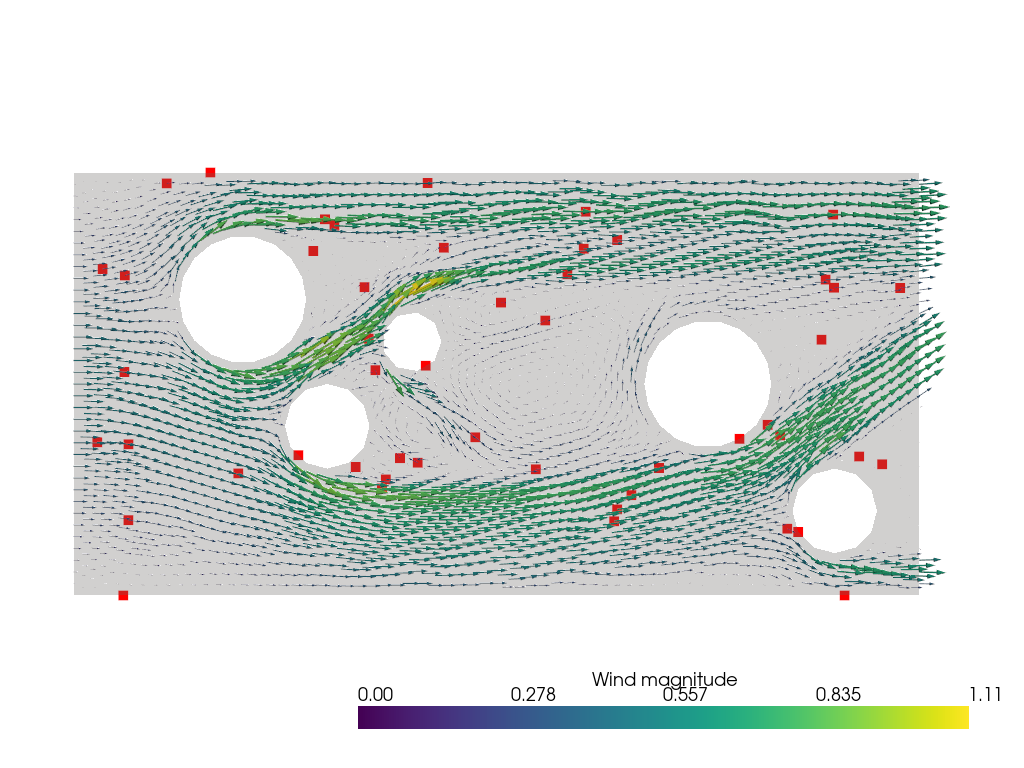

In [4]:
# Load true velocity fields in P2 and P1
u_true = fem.Function(V)
adios4dolfinx.read_function(wind_file, u_true, name="velocity_H2")

w_true = fem.Function(W)
w_true.sub(0).interpolate(u_true)

# Random P2 samples
coords_P2 = V.tabulate_dof_coordinates()
p = 50
rng = np.random.default_rng(1)
sample_ids = rng.choice(len(coords_P2), size=p, replace=False)

x_ids = sample_ids * 2
y_ids = sample_ids * 2 + 1

velocity_ids_V = np.stack((x_ids, y_ids)).T.flatten()
measurement_ids_W = V_to_W[velocity_ids_V]

w_measured = fem.Function(W)
w_measured.x.array[:] = 0.0
w_measured.x.array[measurement_ids_W] = w_true.x.array[measurement_ids_W]

measure_mask_W = fem.Function(W)
measure_mask_W.x.array[:] = 0.0
measure_mask_W.x.array[measurement_ids_W] = 1.0

topology, cell_type, geom = plot.vtk_mesh(V)
grid = pv.UnstructuredGrid(topology, cell_type, geom)

wind2d = u_true.x.array.reshape(-1, 2)
wind3d = np.hstack((wind2d, np.zeros((wind2d.shape[0], 1))))
grid.point_data["wind_vectors"] = wind3d

subset = grid.extract_points(np.arange(grid.n_points))
glyphs = subset.glyph(orient="wind_vectors", scale="wind_vectors", factor=0.1)

measured = pv.PolyData(coords_P2[sample_ids])

# --- Plot ---
pl = pv.Plotter()
pl.add_mesh(grid, color="gray", opacity=0.3)
pl.add_mesh(glyphs, scalar_bar_args={"title": "Wind magnitude"})
pl.add_mesh(measured, color="red", point_size=10, label="Sample DOFs (P2)")
pl.view_xy()
pl.zoom_camera(1.3)
pl.show()

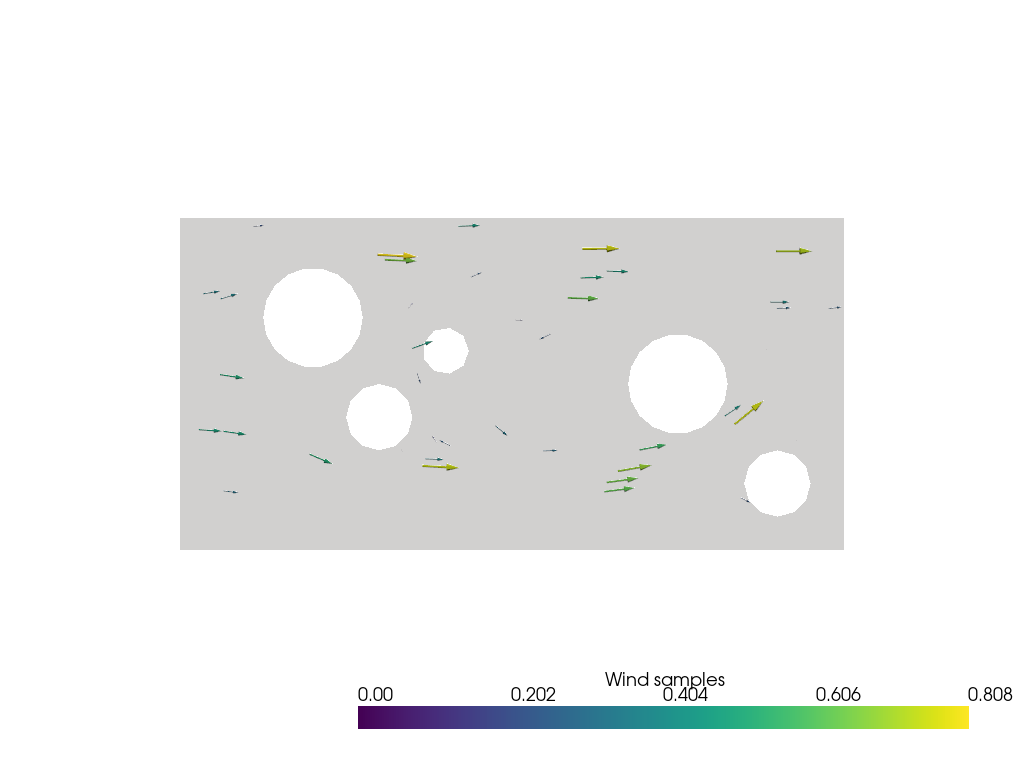

In [5]:
u_measured_V = w_measured.sub(0).collapse()

samples2d = u_measured_V.x.array.reshape(-1, 2)
samples3d = np.hstack((samples2d, np.zeros((samples2d.shape[0], 1))))
grid.point_data["wind_samples"] = samples3d

subset = grid.extract_points(np.arange(grid.n_points))
glyphs = subset.glyph(orient="wind_samples", scale="wind_samples", factor=0.15)

pl = pv.Plotter()
pl.add_mesh(grid, color="gray", opacity=0.3)
pl.add_mesh(glyphs, scalar_bar_args={"title": "Wind samples"})
pl.view_xy()
pl.show()

In [15]:
# No slip boundary conditions on obstacles and walls
u_D_no_slip = fem.Function(V)
u_D_no_slip.x.array[:] = 0.0
no_slip_names = ["Walls", "Obstacle1", "Obstacle2", "Obstacle3", "Obstacle4", "Obstacle5"]
dofs_local = np.concatenate([facet_tags.find(name_to_id[name]) for name in no_slip_names])
dofs = fem.locate_dofs_topological((W0, V), V.mesh.topology.dim - 1, dofs_local)

bc_no_slip = fem.dirichletbc(u_D_no_slip, dofs, W0)

def visualize_mixed(mixed_function: fem.Function, scale=1.0):
    u_c = mixed_function.sub(0).collapse()
    p_c = mixed_function.sub(1).collapse()

    u_grid = pv.UnstructuredGrid(*plot.vtk_mesh(u_c.function_space))

    # Pad u to be 3D
    gdim = u_c.function_space.mesh.geometry.dim
    assert len(u_c) == gdim
    u_values = np.zeros((len(u_c.x.array) // gdim, 3), dtype=np.float64)
    u_values[:, :gdim] = u_c.x.array.real.reshape((-1, gdim))

    # Create a point cloud of glyphs
    u_grid["u"] = u_values
    glyphs = u_grid.glyph(orient="u", factor=scale)
    plotter = pv.Plotter()
    plotter.add_mesh(u_grid, show_edges=False, show_scalar_bar=False)
    plotter.add_mesh(glyphs)
    plotter.view_xy()
    plotter.show()

    p_grid = pv.UnstructuredGrid(*plot.vtk_mesh(p_c.function_space))
    p_grid.point_data["p"] = p_c.x.array
    plotter_p = pv.Plotter()
    plotter_p.add_mesh(p_grid, show_edges=False)
    plotter_p.view_xy()
    plotter_p.show()

# Outflow - zero pressure
p_zero = fem.Function(Q)
p_zero.x.array[:] = 1.0
p_1_facets = ["Obstacle1", "Obstacle2", "Obstacle3", "Obstacle4", "Obstacle5"]
dofs_local = np.concatenate([facet_tags.find(name_to_id[name]) for name in p_1_facets])
dofs_out = fem.locate_dofs_topological((W1, Q), V.mesh.topology.dim - 1, dofs_local)

bc_out = fem.dirichletbc(p_zero, dofs_out, W1)


# # Pressure set = 1 (One point)
# p_zero = fem.Function(Q)
# p_zero.x.array[:] = 1.0
# dofs = fem.locate_dofs_geometrical((W1, Q), lambda x: np.isclose(x[0], 0.0) & np.isclose(x[1], 0.0))

# bc_offset = fem.dirichletbc(p_zero, dofs, W1)

In [16]:
def forms_LS(W: fem.FunctionSpace,
             wh_prev: fem.Function,
             w_measured: fem.Function,
             mask_scalar: fem.Function,   # <<— SKALAR! (z.B. P2 scalar)
             nu_value: float | None = 1.5e-4,
             alpha_val: float | None = 1.0,
             beta_val: float | None = 1.0,
             gamma_val: float | None = 1e-3):

    domain = W.mesh
    nu    = fem.Constant(domain, PETSc.ScalarType(nu_value))
    alpha = fem.Constant(domain, PETSc.ScalarType(alpha_val))
    beta  = fem.Constant(domain, PETSc.ScalarType(beta_val))
    gamma = fem.Constant(domain, PETSc.ScalarType(gamma_val))

    uh_prev, _   = wh_prev.split()       # given Picard field (fixed)
    u_meas,  _   = w_measured.split()    # measured velocity in W (p-part 0)

    (u, p) = ufl.TrialFunctions(W)
    (v, q) = ufl.TestFunctions(W)

    # Picard-linearised strong residuals for Trial and Test sides
    Rmom_u = -nu*ufl.div(ufl.grad(u)) + ufl.dot(uh_prev, ufl.grad(u)) + ufl.grad(p)
    Rmom_v = -nu*ufl.div(ufl.grad(v)) + ufl.dot(uh_prev, ufl.grad(v)) + ufl.grad(q)
    Rdiv_u = ufl.div(u)
    Rdiv_v = ufl.div(v)

    # Bilinear form: data + LS(PDE) + H1 reg
    a_ls = (
        alpha * ufl.inner(mask_scalar * u, mask_scalar * v)
        + beta * ( ufl.inner(Rmom_u, Rmom_v) + Rdiv_u*Rdiv_v )
        + gamma * ufl.inner(ufl.grad(u), ufl.grad(v))
    ) * ufl.dx

    # Linear form (from data term)
    L_ls = ufl.inner(mask_scalar * u_meas, mask_scalar * v) * ufl.dx
    
    return a_ls, L_ls

def evaluate_J_terms(W: fem.FunctionSpace,
                     wh_prev: fem.Function,
                     wh_sol: fem.Function,
                     w_measured: fem.Function,
                     mask_scalar: fem.Function,
                     nu_value: float = 1.5e-4,
                     alpha_val: float = 1.0,
                     beta_val: float = 1.0,
                     gamma_val: float = 1e-3):
    """
    Evaluate individual least-squares functional contributions (data, PDE, reg)
    for the current solution wh_sol, using the same definitions as in forms_LS().
    """

    domain = W.mesh
    nu    = fem.Constant(domain, PETSc.ScalarType(nu_value))
    alpha = fem.Constant(domain, PETSc.ScalarType(alpha_val))
    beta  = fem.Constant(domain, PETSc.ScalarType(beta_val))
    gamma = fem.Constant(domain, PETSc.ScalarType(gamma_val))

    # Split functions
    u_prev, _ = wh_prev.split()
    u_sol, p_sol = wh_sol.split()
    u_meas, _ = w_measured.split()

    # Rebuild residuals with actual solved fields
    Rmom = -nu * ufl.div(ufl.grad(u_sol)) + ufl.dot(u_prev, ufl.grad(u_sol)) + ufl.grad(p_sol)
    Rdiv = ufl.div(u_sol)

    # Data misfit
    J_data = 0.5 * fem.assemble_scalar(fem.form(
        alpha * ufl.inner(mask_scalar * (u_sol - u_meas),
                          mask_scalar * (u_sol - u_meas)) * ufl.dx
    ))

    # PDE residual term
    J_pde = 0.5 * fem.assemble_scalar(fem.form(
        beta * (ufl.inner(Rmom, Rmom) + Rdiv * Rdiv) * ufl.dx
    ))

    # H1 regularisation
    J_reg = 0.5 * fem.assemble_scalar(fem.form(
        gamma * ufl.inner(ufl.grad(u_sol), ufl.grad(u_sol)) * ufl.dx
    ))

    return J_data, J_pde, J_reg

def petsc_to_numpy(petsc_obj):
    
    # PETSc Matrix (Mat)
    if isinstance(petsc_obj, PETSc.Mat):
        rows, cols = petsc_obj.getSize()
        np_array = petsc_obj.getValues(range(rows), range(cols))
        
        return np_array
    
    # PETSc Vector (Vec)
    elif isinstance(petsc_obj, PETSc.Vec):
        return petsc_obj.getArray()
        
    else:
        raise TypeError(f"Unknown PETSc- type: {type(petsc_obj)}. Expecting Mat or Vec.")

Iter 0: Δ=8.998e+01,  J_data=5.167e-03,  J_pde=1.438e-03,  J_reg=4.092e-08
‖Rmom(u_sol,p_sol)‖² = 1.9569957985273143e-07
Iter 1: Δ=6.299e+01,  J_data=5.167e-03,  J_pde=1.586e-03,  J_reg=1.043e-07
‖Rmom(u_sol,p_sol)‖² = 2.6721140999975664e-07
Iter 2: Δ=4.409e+01,  J_data=5.166e-03,  J_pde=1.774e-03,  J_reg=2.464e-07
‖Rmom(u_sol,p_sol)‖² = 3.131871159063472e-07
Iter 3: Δ=3.086e+01,  J_data=5.163e-03,  J_pde=4.878e-03,  J_reg=1.364e-06
‖Rmom(u_sol,p_sol)‖² = 8.85398812026643e-07
Iter 4: Δ=2.153e+01,  J_data=5.642e-03,  J_pde=9.876e+01,  J_reg=4.816e-02
‖Rmom(u_sol,p_sol)‖² = 0.018525195186393426
Iter 5: Δ=2.772e+01,  J_data=5.191e-03,  J_pde=1.242e+02,  J_reg=4.068e-02
‖Rmom(u_sol,p_sol)‖² = 0.00969580486756717
Iter 6: Δ=1.501e+01,  J_data=9.967e-03,  J_pde=5.022e+04,  J_reg=2.584e+00
‖Rmom(u_sol,p_sol)‖² = 9.800194835011805
Iter 7: Δ=1.363e+01,  J_data=6.202e-03,  J_pde=3.507e+04,  J_reg=1.002e+00
‖Rmom(u_sol,p_sol)‖² = 6.658823050926334
Iter 8: Δ=1.342e+01,  J_data=5.147e-03,  J_pde=1.7

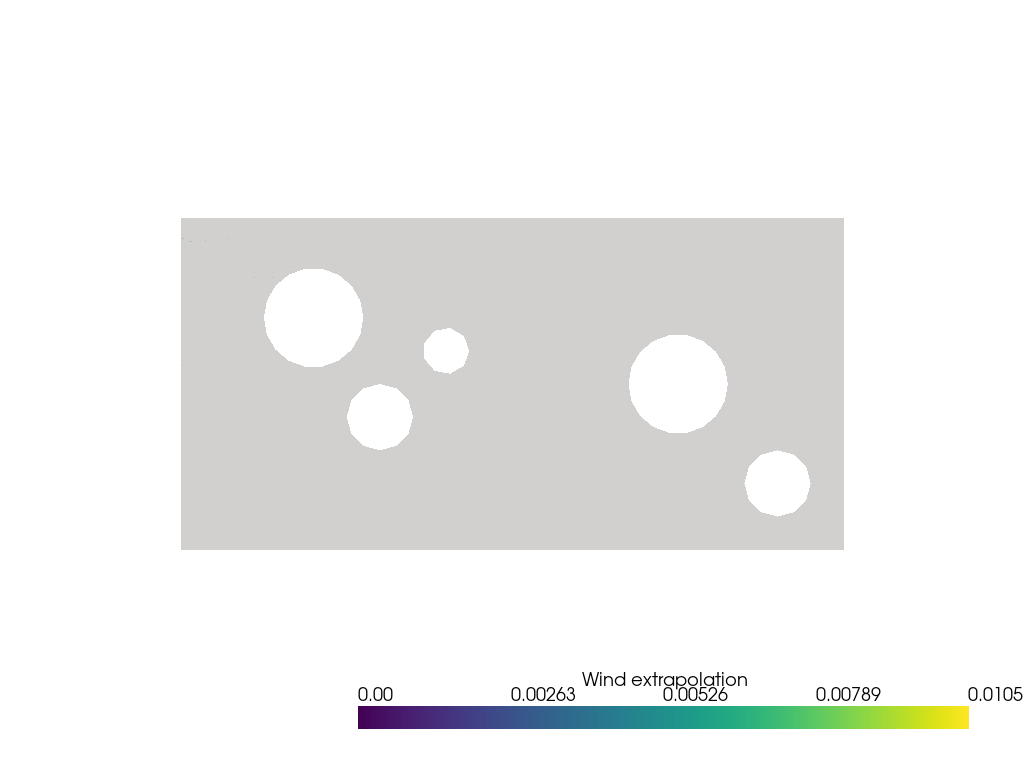

In [18]:
maxit = 50

V_scalar = fem.functionspace(domain, ("Lagrange", 2))
mask_fun = fem.Function(V_scalar)
mask_fun.x.array[sample_ids] = 1.0

wh_prev = fem.Function(W)
wh_prev.x.array[:] = np.random.normal(0, 1, len(wh_prev.x.array))

for k in range(maxit):

    alpha = 1e2
    beta  = 1e4
    gamma = 1e-1
    omega = 0.3
    a, L = forms_LS(W, wh_prev, w_measured, mask_fun, 
                    alpha_val=alpha, 
                    beta_val=beta, 
                    gamma_val=gamma)
    
    solver = LinearProblem(a, L, bcs=[bc_no_slip, bc_out])
    wh_new = solver.solve()

    diff = np.linalg.norm(wh_new.x.array - wh_prev.x.array)

    Jd, Jp, Jr = evaluate_J_terms(W, wh_prev, wh_new, w_measured, mask_fun,
                                  nu_value=1.5e-4, alpha_val=alpha, beta_val=beta, gamma_val=gamma)

    print(f"Iter {k}: Δ={diff:.3e},  J_data={Jd:.3e},  J_pde={Jp:.3e},  J_reg={Jr:.3e}")

    u_prev, _   = wh_prev.split()
    u_sol, p_sol = wh_new.split()

    Rmom_sol = -nu*ufl.div(ufl.grad(u_sol)) + ufl.dot(u_prev, ufl.grad(u_sol)) + ufl.grad(p_sol)
    val = fem.assemble_scalar(fem.form(ufl.inner(Rmom_sol, Rmom_sol) * ufl.dx))
    print("‖Rmom(u_sol,p_sol)‖² =", val)

    wh_prev.x.array[:] = (1-omega)*wh_prev.x.array + omega*wh_new.x.array

# Visualize result
u_final = wh_new.sub(0).collapse()

samples2d = u_final.x.array.reshape(-1, 2)
samples3d = np.hstack((samples2d, np.zeros((samples2d.shape[0], 1))))
grid.point_data["wind_extrapolation"] = samples3d

subset = grid.extract_points(np.arange(grid.n_points))
glyphs = subset.glyph(orient="wind_extrapolation", scale="wind_extrapolation", factor=1.0)

pl = pv.Plotter()
pl.add_mesh(grid, color="gray", opacity=0.3)
pl.add_mesh(glyphs, scalar_bar_args={"title": "Wind extrapolation"})
pl.view_xy()
pl.show()
    